In [1]:
import os
import numpy as np
from PIL import Image
from pathlib import Path

def load_images_recursively(root_path, extensions=None):
    """
    Recursively load all images from a directory structure into a numpy array.
    
    Parameters:
    -----------
    root_path : str
        Root directory to search for images
    extensions : list, optional
        List of image extensions to include (e.g., ['.png', '.jpg', '.tif'])
        If None, defaults to common image formats
    
    Returns:
    --------
    images : numpy.ndarray
        Array of shape (n_images, height, width, channels) or (n_images, height, width)
    paths : list
        List of relative paths for each image
    """
    if extensions is None:
        extensions = ['.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp']
    
    # Convert to lowercase for case-insensitive matching
    extensions = [ext.lower() for ext in extensions]
    
    images = []
    paths = []
    
    # Walk through directory tree
    for root, dirs, files in os.walk(root_path):
        for file in sorted(files):
            # Check if file has valid image extension
            if any(file.lower().endswith(ext) for ext in extensions):
                img_path = os.path.join(root, file)
                
                try:
                    # Load image
                    img = Image.open(img_path)
                    img_array = np.array(img)
                    
                    images.append(img_array)
                    # Store relative path from root
                    rel_path = os.path.relpath(img_path, root_path)
                    paths.append(rel_path)
                    
                except Exception as e:
                    print(f"Error loading {img_path}: {e}")
    
    if not images:
        print(f"No images found in {root_path}")
        return np.array([]), []
    
    # Check if all images have the same shape
    shapes = [img.shape for img in images]
    if len(set(shapes)) == 1:
        # All same shape - stack into single array
        images_array = np.stack(images, axis=0)
    else:
        print("Warning: Images have different shapes. Returning as list.")
        print(f"Found shapes: {set(shapes)}")
        images_array = np.array(images, dtype=object)
    
    return images_array, paths



In [13]:
root_path = "/group/jug/aman/Cilia_Datasets/W19 - 2025_Pkhd1 cells_masks/"

# Load all images
images, paths = load_images_recursively(root_path)

print(f"Loaded {len(images)} images")
if len(images) > 0:
    print(f"Images shape: {images.shape}")
    print(f"\nFirst few image paths:")
    for i, path in enumerate(paths):
        print(f"  {i}: {path}")

Loaded 291 images
Images shape: (291, 65, 65)

First few image paths:
  0: CCDC92, Y-tub, Arl13b, DAPI/Pkhd1 KO/Cropped original image/single cilia image01/IMCD3 Pkhd KO - CCDC92, ARL13B, Y-TUB, DAPI_1-10cilia_CQP_ed.tif
  1: CCDC92, Y-tub, Arl13b, DAPI/Pkhd1 KO/Cropped original image/single cilia image01/IMCD3 Pkhd KO - CCDC92, ARL13B, Y-TUB, DAPI_1-11cilia_CQP_ed.tif
  2: CCDC92, Y-tub, Arl13b, DAPI/Pkhd1 KO/Cropped original image/single cilia image01/IMCD3 Pkhd KO - CCDC92, ARL13B, Y-TUB, DAPI_1-12cilia_CQP_ed.tif
  3: CCDC92, Y-tub, Arl13b, DAPI/Pkhd1 KO/Cropped original image/single cilia image01/IMCD3 Pkhd KO - CCDC92, ARL13B, Y-TUB, DAPI_1-13cilia_CQP_ed.tif
  4: CCDC92, Y-tub, Arl13b, DAPI/Pkhd1 KO/Cropped original image/single cilia image01/IMCD3 Pkhd KO - CCDC92, ARL13B, Y-TUB, DAPI_1-14cilia_CQP_ed.tif
  5: CCDC92, Y-tub, Arl13b, DAPI/Pkhd1 KO/Cropped original image/single cilia image01/IMCD3 Pkhd KO - CCDC92, ARL13B, Y-TUB, DAPI_1-15cilia_CQP_ed.tif
  6: CCDC92, Y-tub, Arl1

In [11]:
import zipfile
from pathlib import Path

def unzip_recursive(zip_path, dest_dir):
    dest = Path(dest_dir)
    with zipfile.ZipFile(zip_path) as z:
        for info in z.infolist():
            print("Extracting:", info.filename)
            out = z.extract(info, dest)
            # If the extracted file is another zip, extract recursively
            if out.endswith(".zip"):
                print("Found nested zip:", out)
                unzip_recursive(out, dest / Path(info.filename).stem)

unzip_recursive("/group/jug/aman/Cilia_Datasets/bluewhale1764075303209.zip",
                "/group/jug/aman/Cilia_Datasets/extracted")


Extracting: W19_-_2025_Pkhd1_cells.zip
Found nested zip: /group/jug/aman/Cilia_Datasets/extracted/W19_-_2025_Pkhd1_cells.zip
Extracting: W19 - 2025_Pkhd1 cells/
Extracting: __MACOSX/._W19 - 2025_Pkhd1 cells
Extracting: W19 - 2025_Pkhd1 cells/CCDC92, Y-tub, Arl13b, DAPI/
Extracting: W19 - 2025_Pkhd1 cells/.DS_Store
Extracting: __MACOSX/W19 - 2025_Pkhd1 cells/._.DS_Store
Extracting: W19 - 2025_Pkhd1 cells/ZDHHC5, Y-tub, Arl13, DAPI/
Extracting: W19 - 2025_Pkhd1 cells/CCDC92, Y-tub, Arl13b, DAPI/.DS_Store
Extracting: __MACOSX/W19 - 2025_Pkhd1 cells/CCDC92, Y-tub, Arl13b, DAPI/._.DS_Store
Extracting: W19 - 2025_Pkhd1 cells/CCDC92, Y-tub, Arl13b, DAPI/Pkhd1 CTRL/
Extracting: W19 - 2025_Pkhd1 cells/CCDC92, Y-tub, Arl13b, DAPI/Pkhd1 KO/
Extracting: W19 - 2025_Pkhd1 cells/ZDHHC5, Y-tub, Arl13, DAPI/.DS_Store
Extracting: __MACOSX/W19 - 2025_Pkhd1 cells/ZDHHC5, Y-tub, Arl13, DAPI/._.DS_Store
Extracting: W19 - 2025_Pkhd1 cells/ZDHHC5, Y-tub, Arl13, DAPI/Pkhd1 CTRL/
Extracting: W19 - 2025_Pkhd1 ce

In [17]:
import os
import shutil
from pathlib import Path
from collections import defaultdict
import re
import numpy as np
from PIL import Image

def organize_cilia_dataset(source_root, target_root):
    """
    Extract and organize images with their corresponding CiliaQ masks.
    _CQP_ed.tif files are INPUT images
    _CQ_C*.tif files are OUTPUT masks (from CQ folders)
    
    Parameters:
    -----------
    source_root : str
        Root directory of extracted data
    target_root : str
        Target directory for organized dataset
    """
    
    target_path = Path(target_root)
    target_path.mkdir(parents=True, exist_ok=True)
    
    stats = defaultdict(int)
    image_files = []
    mask_files = []
    
    # Walk through source directory
    for root, dirs, files in os.walk(source_root):
        root_path = Path(root)
        
        # Skip unwanted directories
        if any(skip in root for skip in ['__MACOSX', '_temp', '.DS_Store']):
            continue
        
        for file in files:
            if not file.lower().endswith(('.tif', '.tiff')):
                continue
                
            file_path = root_path / file
            
            # Parse the path
            parts = root_path.relative_to(source_root).parts
            
            try:
                staining = parts[0] if len(parts) > 0 else 'unknown'
                condition = parts[1] if len(parts) > 1 else 'unknown'
                
                # Clean up
                if 'CTRL' in condition:
                    condition = 'CTRL'
                elif 'KO' in condition:
                    condition = 'KO'
                staining = staining.split(',')[0].strip()
                
                # Categorize file
                if '_CQP_ed' in file:
                    # INPUT IMAGE for CiliaQ
                    image_files.append({
                        'path': file_path,
                        'filename': file,
                        'staining': staining,
                        'condition': condition,
                        'base_name': file.replace('_CQP_ed.tif', '').replace('_CQP_ed.tiff', '')
                    })
                    stats['input_images'] += 1
                    
                elif '_CQ_C' in file or (root_path.name.endswith('_CQ') and file.startswith('CQ_')):
                    # OUTPUT MASK from CiliaQ
                    # Extract the parent folder name to match with input
                    parent_folder = root_path.name
                    base_name = parent_folder.replace('_CQP_ed_CQ', '').replace('_CQ', '')
                    
                    mask_files.append({
                        'path': file_path,
                        'filename': file,
                        'staining': staining,
                        'condition': condition,
                        'base_name': base_name,
                        'parent_folder': parent_folder
                    })
                    stats['mask_files'] += 1
                    
            except Exception as e:
                print(f"Error processing {file_path}: {e}")
                stats['errors'] += 1
    
    # Create organized structure
    print("Organizing files...")
    
    # Copy input images
    for img_info in image_files:
        target_dir = target_path / 'images' / img_info['condition'] / img_info['staining']
        target_dir.mkdir(parents=True, exist_ok=True)
        
        target_file = target_dir / img_info['filename']
        if not target_file.exists():
            shutil.copy2(img_info['path'], target_file)
    
    # Copy masks and create pairs mapping
    pairs_mapping = defaultdict(list)
    
    for mask_info in mask_files:
        target_dir = target_path / 'masks' / mask_info['condition'] / mask_info['staining']
        target_dir.mkdir(parents=True, exist_ok=True)
        
        # Create a subfolder for each image's masks
        mask_subfolder = target_dir / mask_info['parent_folder']
        mask_subfolder.mkdir(parents=True, exist_ok=True)
        
        target_file = mask_subfolder / mask_info['filename']
        if not target_file.exists():
            shutil.copy2(mask_info['path'], target_file)
        
        # Track this mask for pairing
        key = (mask_info['condition'], mask_info['staining'], mask_info['base_name'])
        pairs_mapping[key].append(str(mask_subfolder / mask_info['filename']))
    
    # Create pairs file
    create_pairs_file(target_path, image_files, pairs_mapping)
    
    # Print summary
    print("\n" + "="*60)
    print("DATASET ORGANIZATION SUMMARY")
    print("="*60)
    print(f"\nSource: {source_root}")
    print(f"Target: {target_root}")
    print(f"\nFiles organized:")
    print(f"  - Input images (_CQP_ed): {stats['input_images']}")
    print(f"  - Output masks (_CQ_C*): {stats['mask_files']}")
    
    if stats['errors'] > 0:
        print(f"\nErrors encountered: {stats['errors']}")
    
    return stats


def create_pairs_file(target_path, image_files, pairs_mapping):
    """Create a detailed pairs mapping file."""
    
    pairs_file = target_path / 'image_mask_pairs.txt'
    paired_count = 0
    unpaired_count = 0
    
    with open(pairs_file, 'w') as f:
        f.write("IMAGE-MASK PAIRS FOR CILIA SEGMENTATION\n")
        f.write("=" * 70 + "\n\n")
        f.write("Format: INPUT IMAGE -> OUTPUT MASKS\n")
        f.write("  Channel 1 (cyan): reconstructed cilium\n")
        f.write("  Channel 2 (white): cell skeleton\n")
        f.write("  Channel 3 (green): intensity A\n")
        f.write("  Channel 4 (red): intensity B\n\n")
        
        by_condition = defaultdict(list)
        
        for img_info in sorted(image_files, key=lambda x: (x['condition'], x['staining'], x['filename'])):
            key = (img_info['condition'], img_info['staining'], img_info['base_name'])
            masks = pairs_mapping.get(key, [])
            
            by_condition[img_info['condition']].append({
                'staining': img_info['staining'],
                'image': img_info['filename'],
                'masks': masks
            })
            
            if masks:
                paired_count += 1
            else:
                unpaired_count += 1
        
        # Write organized by condition
        for condition in sorted(by_condition.keys()):
            f.write(f"\n{'='*70}\n")
            f.write(f"{condition} CONDITION\n")
            f.write(f"{'='*70}\n\n")
            
            for item in by_condition[condition]:
                f.write(f"Image: {item['image']}\n")
                f.write(f"  Staining: {item['staining']}\n")
                if item['masks']:
                    f.write(f"  Masks ({len(item['masks'])}):\n")
                    for mask in item['masks']:
                        f.write(f"    - {Path(mask).name}\n")
                else:
                    f.write(f"  Masks: NONE FOUND\n")
                f.write("\n")
        
        f.write(f"\n{'='*70}\n")
        f.write(f"SUMMARY\n")
        f.write(f"{'='*70}\n")
        f.write(f"Images with masks: {paired_count}\n")
        f.write(f"Images without masks: {unpaired_count}\n")
        f.write(f"Total images: {paired_count + unpaired_count}\n")
    
    print(f"\nPairs mapping written to: {pairs_file}")
    print(f"  - Paired: {paired_count}")
    print(f"  - Unpaired: {unpaired_count}")


def load_dataset_with_masks(organized_root, condition=None, staining=None):
    """
    Load images with their corresponding CiliaQ masks.
    
    Parameters:
    -----------
    organized_root : str
        Root of organized dataset
    condition : str, optional
        Filter by 'CTRL' or 'KO'
    staining : str, optional
        Filter by staining type (e.g., 'CCDC92', 'ZDHHC5')
    
    Returns:
    --------
    dataset : list of dicts
        Each dict contains:
        - 'image': numpy array (H, W) or (H, W, C)
        - 'masks': dict with channel names and numpy arrays
        - 'image_path': str
        - 'condition': str
        - 'staining': str
        - 'has_masks': bool
    """
    
    dataset = []
    
    images_path = Path(organized_root) / 'images'
    masks_path = Path(organized_root) / 'masks'
    
    # Determine which conditions to load
    conditions = [condition] if condition else ['CTRL', 'KO']
    
    for cond in conditions:
        img_cond_path = images_path / cond
        mask_cond_path = masks_path / cond
        
        if not img_cond_path.exists():
            continue
        
        # Get staining folders
        if staining:
            staining_paths = [img_cond_path / staining]
        else:
            staining_paths = [p for p in img_cond_path.iterdir() if p.is_dir()]
        
        for stain_path in staining_paths:
            if not stain_path.exists():
                continue
            
            stain_name = stain_path.name
            mask_stain_path = mask_cond_path / stain_name
            
            # Load each image
            for img_file in sorted(stain_path.glob('*_CQP_ed.tif*')):
                try:
                    # Load image
                    img = Image.open(img_file)
                    img_array = np.array(img)
                    
                    # Find corresponding masks
                    base_name = img_file.stem.replace('_CQP_ed', '')
                    masks_dict = {}
                    
                    if mask_stain_path.exists():
                        # Look for mask folder
                        for mask_folder in mask_stain_path.iterdir():
                            if base_name in mask_folder.name and mask_folder.is_dir():
                                # Load all channel masks
                                for mask_file in mask_folder.glob('CQ_C*.tif*'):
                                    # Extract channel number
                                    ch_match = re.search(r'CQ_C(\d+)', mask_file.name)
                                    if ch_match:
                                        ch_num = int(ch_match.group(1))
                                        mask = Image.open(mask_file)
                                        mask_array = np.array(mask)
                                        
                                        # Map channel numbers to names
                                        ch_names = {
                                            1: 'cilium',
                                            2: 'skeleton',
                                            3: 'intensity_A',
                                            4: 'intensity_B'
                                        }
                                        ch_name = ch_names.get(ch_num, f'channel_{ch_num}')
                                        masks_dict[ch_name] = mask_array
                    
                    dataset.append({
                        'image': img_array,
                        'masks': masks_dict,
                        'image_path': str(img_file),
                        'image_name': img_file.name,
                        'condition': cond,
                        'staining': stain_name,
                        'has_masks': len(masks_dict) > 0,
                        'image_shape': img_array.shape,
                        'n_mask_channels': len(masks_dict)
                    })
                    
                except Exception as e:
                    print(f"Error loading {img_file}: {e}")
    
    # Print summary
    print(f"\nLoaded {len(dataset)} images")
    print(f"Conditions: {set(d['condition'] for d in dataset)}")
    print(f"Stainings: {set(d['staining'] for d in dataset)}")
    print(f"\nWith masks: {sum(1 for d in dataset if d['has_masks'])}")
    print(f"Without masks: {sum(1 for d in dataset if not d['has_masks'])}")
    
    if dataset:
        with_masks = [d for d in dataset if d['has_masks']]
        if with_masks:
            print(f"\nMask channels found: {set(k for d in with_masks for k in d['masks'].keys())}")
            print(f"Image shapes: {set(d['image_shape'] for d in dataset)}")
    
    return dataset


# Example usage
if __name__ == "__main__":
    source_root = "/group/jug/aman/Cilia_Datasets/extracted/W19_-_2025_Pkhd1_cells/W19 - 2025_Pkhd1 cells/"
    target_root = "/group/jug/aman/Cilia_Datasets/organized_for_training"
    
    # Organize the dataset
    print("Organizing dataset...")
    stats = organize_cilia_dataset(source_root, target_root)
    
    print("\n" + "="*60)
    print("NEXT STEPS:")
    print("="*60)
    print("\n1. Load the dataset:")
    print("   dataset = load_dataset_with_masks(target_root)")
    print("\n2. Access data:")
    print("   for item in dataset:")
    print("       image = item['image']  # Input image (65x65)")
    print("       if item['has_masks']:")
    print("           cilium = item['masks']['cilium']  # Main target")
    print("           skeleton = item['masks']['skeleton']")
    print("\n3. Split into train/val/test:")
    print("   from sklearn.model_selection import train_test_split")
    print("   train, test = train_test_split(dataset, test_size=0.2)")
    print("\n4. Train your segmentation model!")
    print("\nNOTE: Check image_mask_pairs.txt to see which images")
    print("      have masks and which don't.")

Organizing dataset...
Organizing files...

Pairs mapping written to: /group/jug/aman/Cilia_Datasets/organized_for_training/image_mask_pairs.txt
  - Paired: 29
  - Unpaired: 58

DATASET ORGANIZATION SUMMARY

Source: /group/jug/aman/Cilia_Datasets/extracted/W19_-_2025_Pkhd1_cells/W19 - 2025_Pkhd1 cells/
Target: /group/jug/aman/Cilia_Datasets/organized_for_training

Files organized:
  - Input images (_CQP_ed): 87
  - Output masks (_CQ_C*): 30

NEXT STEPS:

1. Load the dataset:
   dataset = load_dataset_with_masks(target_root)

2. Access data:
   for item in dataset:
       image = item['image']  # Input image (65x65)
       if item['has_masks']:
           cilium = item['masks']['cilium']  # Main target
           skeleton = item['masks']['skeleton']

3. Split into train/val/test:
   from sklearn.model_selection import train_test_split
   train, test = train_test_split(dataset, test_size=0.2)

4. Train your segmentation model!

NOTE: Check image_mask_pairs.txt to see which images
      ha

In [2]:
import os
import shutil
from pathlib import Path
from collections import defaultdict

def identify_cilia_data(source_root):
    """
    Identify input cilia images and their corresponding CiliaQ masks
    """
    print(f"Scanning: {source_root}\n")
    print("="*70)
    
    input_images = []
    mask_folders = []
    
    for root, dirs, files in os.walk(source_root):
        root_path = Path(root)
        
        # Skip system folders
        if any(skip in str(root_path) for skip in ['__MACOSX', '.DS_Store', '_temp']):
            continue
        
        # Look for "single cilia image" folders containing input TIFs
        if 'single cilia image' in root_path.name:
            for file in files:
                if file.endswith('.tif') and not any(x in file for x in ['_CQP', '_CQ']):
                    # This is an input cilia image
                    input_images.append({
                        'file': file,
                        'path': str(root_path / file),
                        'folder': str(root_path.relative_to(source_root))
                    })
        
        # Look for CiliaQ output folders (end with _CQ)
        if root_path.name.endswith('_CQ'):
            # Check if it contains mask files
            mask_files = [f for f in files if f.startswith('CQ_C') and f.endswith('.tif')]
            if mask_files:
                mask_folders.append({
                    'folder': root_path.name,
                    'path': str(root_path),
                    'masks': mask_files,
                    'parent': str(root_path.relative_to(source_root))
                })
    
    return input_images, mask_folders


def organize_by_structure(input_images, mask_folders, source_root):
    """
    Organize files by condition and staining
    """
    structure = defaultdict(lambda: defaultdict(lambda: {'inputs': [], 'masks': []}))
    
    for img in input_images:
        parts = Path(img['folder']).parts
        if len(parts) >= 2:
            staining = parts[0]  # e.g., "CCDC92, Y-tub, Arl13b, DAPI"
            condition = parts[1]  # e.g., "Pkhd1 CTRL" or "Pkhd1 KO"
            
            # Simplify names
            if 'CTRL' in condition:
                condition = 'CTRL'
            elif 'KO' in condition:
                condition = 'KO'
            
            if 'CCDC92' in staining:
                staining = 'CCDC92'
            elif 'ZDHHC5' in staining:
                staining = 'ZDHHC5'
            
            structure[staining][condition]['inputs'].append(img)
    
    for mask in mask_folders:
        parts = Path(mask['parent']).parts
        if len(parts) >= 2:
            staining = parts[0]
            condition = parts[1]
            
            # Simplify names
            if 'CTRL' in condition:
                condition = 'CTRL'
            elif 'KO' in condition:
                condition = 'KO'
            
            if 'CCDC92' in staining:
                staining = 'CCDC92'
            elif 'ZDHHC5' in staining:
                staining = 'ZDHHC5'
            
            structure[staining][condition]['masks'].append(mask)
    
    return structure


def copy_organized_data(structure, source_root, target_root):
    """
    Copy files in an organized structure
    """
    target_path = Path(target_root)
    target_path.mkdir(parents=True, exist_ok=True)
    
    stats = {'images': 0, 'masks': 0}
    
    print(f"\nCopying to: {target_root}\n")
    
    for staining, conditions in structure.items():
        for condition, data in conditions.items():
            # Copy input images
            for img in data['inputs']:
                target_dir = target_path / 'images' / staining / condition
                target_dir.mkdir(parents=True, exist_ok=True)
                
                source_file = Path(img['path'])
                target_file = target_dir / img['file']
                
                if not target_file.exists():
                    shutil.copy2(source_file, target_file)
                    stats['images'] += 1
            
            # Copy mask folders
            for mask in data['masks']:
                target_dir = target_path / 'masks' / staining / condition
                target_dir.mkdir(parents=True, exist_ok=True)
                
                source_folder = Path(mask['path'])
                target_folder = target_dir / mask['folder']
                
                if not target_folder.exists():
                    shutil.copytree(source_folder, target_folder)
                    stats['masks'] += len(mask['masks'])
    
    return stats


# Main execution
if __name__ == "__main__":
    source_root = "/group/jug/aman/Cilia_Datasets/extracted/W19_-_2025_Pkhd1_cells/W19 - 2025_Pkhd1 cells/"
    target_root = "/group/jug/aman/Cilia_Datasets/Extracted_Relevant_Data_main/"
    
    print("STEP 1: IDENTIFYING CILIA DATA")
    print("="*70)
    
    input_images, mask_folders = identify_cilia_data(source_root)
    
    print(f"\n📊 FOUND:")
    print(f"   Input cilia images: {len(input_images)}")
    print(f"   CiliaQ mask folders: {len(mask_folders)}")
    
    # Organize by structure
    structure = organize_by_structure(input_images, mask_folders, source_root)
    
    print(f"\n📁 ORGANIZED BY:")
    for staining, conditions in structure.items():
        print(f"\n   Staining: {staining}")
        for condition, data in conditions.items():
            print(f"      {condition}:")
            print(f"         - Input images: {len(data['inputs'])}")
            print(f"         - Mask folders: {len(data['masks'])}")
    
    # Show samples
    print(f"\n📋 SAMPLE FILES (first 3 inputs):")
    for i, img in enumerate(input_images[:3]):
        print(f"   {i+1}. {img['file']}")
        print(f"      Location: {img['folder']}")
    
    print(f"\n📋 SAMPLE MASKS (first 3 folders):")
    for i, mask in enumerate(mask_folders[:3]):
        print(f"   {i+1}. {mask['folder']}")
        print(f"      Contains: {', '.join(mask['masks'][:2])}...")
    
    # Ask to proceed
    print("\n" + "="*70)
    response = input("\nProceed with copying? (yes/no): ").strip().lower()
    
    if response in ['yes', 'y']:
        print("\nSTEP 2: COPYING DATA")
        print("="*70)
        
        stats = copy_organized_data(structure, source_root, target_root)
        
        print(f"\n✅ COPY COMPLETE!")
        print(f"   Images copied: {stats['images']}")
        print(f"   Mask folders copied: {stats['masks']} mask files")
        print(f"\n📂 Data organized in: {target_root}")
        print(f"   ├── images/")
        print(f"   │   ├── CCDC92/")
        print(f"   │   │   ├── CTRL/")
        print(f"   │   │   └── KO/")
        print(f"   │   └── ZDHHC5/")
        print(f"   │       ├── CTRL/")
        print(f"   │       └── KO/")
        print(f"   └── masks/")
        print(f"       ├── CCDC92/")
        print(f"       └── ZDHHC5/")
    else:
        print("\n⏸️  Skipped copying.")


# **This script will:**

# 1. **Identify** all input cilia images (the individual `.tif` files)
# 2. **Identify** all CiliaQ mask folders (folders ending in `_CQ` with `CQ_C1.tif` files)
# 3. **Show you** what it found organized by staining and condition
# 4. **Ask for confirmation** before copying
# 5. **Copy** everything in a clean organized structure:
# ```
#    copied_cilia_data/
#    ├── images/
#    │   ├── CCDC92/CTRL/  (input cilia images)
#    │   ├── CCDC92/KO/
#    │   ├── ZDHHC5/CTRL/
#    │   └── ZDHHC5/KO/
#    └── masks/
#        ├── CCDC92/CTRL/  (CiliaQ mask folders)
#        ├── CCDC92/KO/
#        ├── ZDHHC5/CTRL/
#        └── ZDHHC5/KO/

STEP 1: IDENTIFYING CILIA DATA
Scanning: /group/jug/aman/Cilia_Datasets/extracted/W19_-_2025_Pkhd1_cells/W19 - 2025_Pkhd1 cells/


📊 FOUND:
   Input cilia images: 348
   CiliaQ mask folders: 29

📁 ORGANIZED BY:

   Staining: CCDC92
      KO:
         - Input images: 95
         - Mask folders: 29
      CTRL:
         - Input images: 85
         - Mask folders: 0

   Staining: ZDHHC5
      KO:
         - Input images: 84
         - Mask folders: 0
      CTRL:
         - Input images: 84
         - Mask folders: 0

📋 SAMPLE FILES (first 3 inputs):
   1. IMCD3 Pkhd KO - CCDC92, ARL13B, Y-TUB, DAPI_1-5cilia.tif
      Location: CCDC92, Y-tub, Arl13b, DAPI/Pkhd1 KO/Cropped original image/single cilia image01
   2. IMCD3 Pkhd KO - CCDC92, ARL13B, Y-TUB, DAPI_1-6cilia.tif
      Location: CCDC92, Y-tub, Arl13b, DAPI/Pkhd1 KO/Cropped original image/single cilia image01
   3. IMCD3 Pkhd KO - CCDC92, ARL13B, Y-TUB, DAPI_1-1cilia.tif
      Location: CCDC92, Y-tub, Arl13b, DAPI/Pkhd1 KO/Cropped orig

In [ ]:
import os
import numpy as np
import tifffile as tf

path = "/group/jug/aman/Cilia_Datasets/Extracted_Relevant_Data_main/masks/"

images = []
reference_shape = None

for root, dirs, files in os.walk(path):
    for f in files:
        if f.lower().endswith(".tif"):
            img_path = os.path.join(root, f)
            img = tf.imread(img_path)

            # Initialize reference shape with the first image
            if reference_shape is None:
                reference_shape = img.shape
                images.append(img)
            else:
                # Check shape consistency
                if img.shape == reference_shape:
                    images.append(img)
                else:
                    print(f"Skipping (inhomogeneous shape {img.shape}): {img_path}")

# Convert homogeneous images to array
images = np.array(images)
print("Final array shape:", images.shape)


Skipping (inhomogeneous shape (15, 4, 65, 65)): /group/jug/aman/Cilia_Datasets/Extracted_Relevant_Data_main/images/ZDHHC5/KO/IMCD3 Pkhd KO - Zdhhc5, ARL13B, Y-TUB, DAPI_1-8cilia.tif
Skipping (inhomogeneous shape (16, 4, 65, 65)): /group/jug/aman/Cilia_Datasets/Extracted_Relevant_Data_main/images/ZDHHC5/KO/IMCD3 Pkhd KO - Zdhhc5, ARL13B, Y-TUB, DAPI_9-25cilia.tif
Skipping (inhomogeneous shape (16, 4, 65, 65)): /group/jug/aman/Cilia_Datasets/Extracted_Relevant_Data_main/images/ZDHHC5/KO/IMCD3 Pkhd KO - Zdhhc5, ARL13B, Y-TUB, DAPI_9-13cilia.tif
Skipping (inhomogeneous shape (16, 4, 65, 65)): /group/jug/aman/Cilia_Datasets/Extracted_Relevant_Data_main/images/ZDHHC5/KO/IMCD3 Pkhd KO - Zdhhc5, ARL13B, Y-TUB, DAPI_9-16cilia.tif
Skipping (inhomogeneous shape (16, 4, 65, 65)): /group/jug/aman/Cilia_Datasets/Extracted_Relevant_Data_main/images/ZDHHC5/KO/IMCD3 Pkhd KO - Zdhhc5, ARL13B, Y-TUB, DAPI_9-23cilia.tif
Skipping (inhomogeneous shape (16, 4, 65, 65)): /group/jug/aman/Cilia_Datasets/Extract

In [42]:
import os
import numpy as np
import tifffile as tf

path = "/group/jug/aman/Cilia_Datasets/Extracted_Relevant_Data_main/masks/CCDC92/KO/"

imgs = []
shapes = []
paths = []

for root, dirs, files in os.walk(path):
    for f in files:
        if f.lower().endswith(".tif"):
            img_path = os.path.join(root, f)
            img = tf.imread(img_path)
            imgs.append(img)
            shapes.append(img.shape)
            paths.append(img_path)


In [43]:
max_shape = tuple(np.max(np.array(shapes), axis=0))
mean_shape = tuple(np.mean(np.array(shapes), axis=0))
min_shape = tuple(np.min(np.array(shapes), axis=0))
print("Max shape:", max_shape)
print("mean shape:", mean_shape)
print("min shape:", min_shape)


Max shape: (np.int64(14), np.int64(4), np.int64(35), np.int64(30))
mean shape: (np.float64(11.833333333333334), np.float64(4.0), np.float64(20.7), np.float64(18.766666666666666))
min shape: (np.int64(10), np.int64(4), np.int64(14), np.int64(14))


In [44]:
shapes[0]

(13, 4, 16, 23)

In [45]:
def place_in_canvas(img, target_shape):
    canvas = np.zeros(target_shape, dtype=img.dtype)

    slices = tuple(slice(0, s) for s in img.shape)
    canvas[slices] = img
    return canvas


In [46]:
padded_imgs = np.array([place_in_canvas(img, max_shape) for img in imgs])
print("Final stacked shape:", padded_imgs.shape)


Final stacked shape: (30, 14, 4, 35, 30)


In [5]:
tf.imwrite('/group/jug/aman/Cilia_Datasets/Extracted_Relevant_Data_main/masks/masks.tiff',padded_imgs)

In [1]:
images_path = f"/group/jug/aman/Cilia_Datasets/Extracted_Relevant_Data_main/images/CCDC92/KO/IMCD3 Pkhd KO - CCDC92, ARL13B, Y-TUB, DAPI_7-"
imgs = []
for i in range(1,31):
    imgs.append(tf.imread(images_path+f"{i}cilia.tif"))
imgs = np.array(imgs)

NameError: name 'tf' is not defined

In [26]:
imgs.shape

(30, 15, 4, 65, 65)

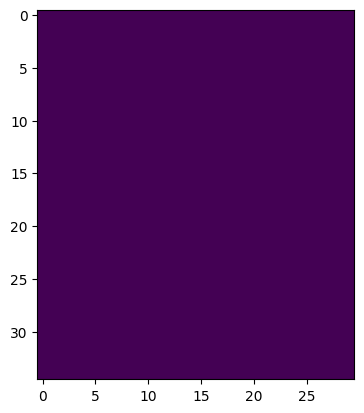

In [50]:
import matplotlib.pyplot as plt
plt.imshow(padded_imgs[0,10,1,...])
